# Notebook 05: Evaluation, Time Series & Tổng kết

### Mục tiêu
- Dự báo cancellation rate theo tháng (Time Series)
- Tổng hợp kết quả tất cả nhánh
- Thảo luận ưu/nhược các phương pháp
- ≥5 actionable insights
- Tổng kết và hướng phát triển

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import load_config
from src.models.forecasting import (
    compute_monthly_cancel_rate, split_time_series,
    check_stationarity, forecast_naive,
    forecast_moving_average, forecast_arima,
    forecast_holt_winters, run_all_forecasts,
)
from src.evaluation.report import (
    save_results, generate_summary_report,
)
from src.visualization.plots import (
    plot_time_series_forecast, plot_residuals,
)

config = load_config("../configs/params.yaml")
ts_cfg = config.get('time_series', {})

## 1. Chuỗi thời gian: Dự báo Cancellation Rate

### 1.1 Tạo chuỗi thời gian

[Forecast] Monthly cancel rate: 26 months (2015-07 ~ 2017-08)


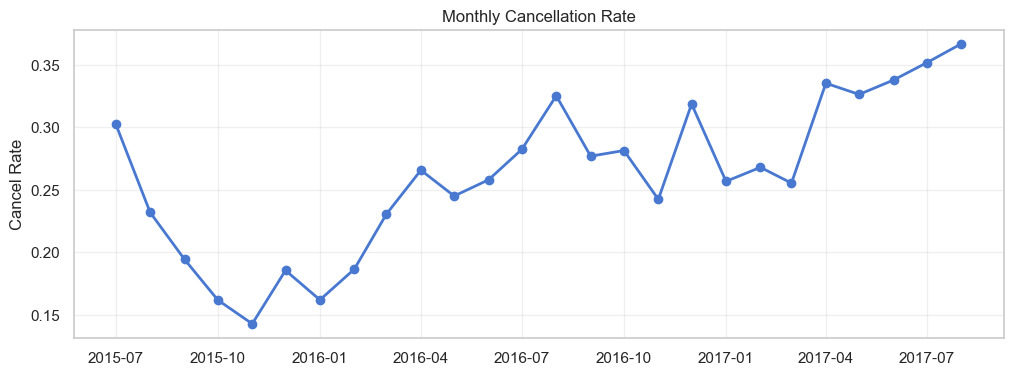

In [2]:
df = pd.read_csv("../" + config["data"]["processed_path"])
cancel_rate = compute_monthly_cancel_rate(df)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cancel_rate.index, cancel_rate.values, "b-o", linewidth=2)
ax.set_title("Monthly Cancellation Rate")
ax.set_ylabel("Cancel Rate")
ax.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/05_monthly_cancel_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Kiểm tra tính dừng

In [3]:
stationarity = check_stationarity(cancel_rate)

[Forecast] ADF test: stat=-0.8435, p=0.806, stationary=False


### 1.3 Train/Test Split

In [4]:
train_ts, test_ts = split_time_series(
    cancel_rate, train_ratio=ts_cfg.get('train_ratio', 0.8),
)

[Forecast] Split: train=20 months, test=6 months


### 1.4 So sánh các phương pháp dự báo

In [5]:
ts_results = run_all_forecasts(
    train_ts, test_ts,
    seasonal_periods=ts_cfg.get('seasonal_periods', 12),
)
save_results(ts_results, "../outputs/tables/time_series")
ts_results

[Forecast] ARIMA(1, 1, 1): AIC=-64.63
[Forecast] Not enough data for seasonal (need 24, have 20). Using additive trend only.

[Forecast] === Comparison ===
            method    mae   rmse  smape
Moving Average (3) 0.0563 0.0594  18.18
             Naive 0.0651 0.0704  21.32
      Holt-Winters 0.0694 0.0756  22.93
      ARIMA(1,1,1) 0.0732 0.0795  24.43
[Report] Saved CSV: ..\outputs\tables\time_series.csv
[Report] Saved JSON: ..\outputs\tables\time_series.json


,method,mae,rmse,smape
1,Moving Average (3),0.0563,0.0594,18.18
0,Naive,0.0651,0.0704,21.32
3,Holt-Winters,0.0694,0.0756,22.93
2,"ARIMA(1,1,1)",0.0732,0.0795,24.43


### 1.5 Visualization

In [6]:
n_periods = len(test_ts)

forecasts = {}
forecasts['Naive'] = forecast_naive(train_ts, n_periods)
forecasts['MA(3)'] = forecast_moving_average(train_ts, n_periods)
try:
    fc_arima, _ = forecast_arima(train_ts, n_periods)
    forecasts['ARIMA'] = fc_arima
except: pass
try:
    sp = ts_cfg.get('seasonal_periods', 12)
    fc_hw, _ = forecast_holt_winters(train_ts, n_periods, sp)
    forecasts['Holt-Winters'] = fc_hw
except: pass

plot_time_series_forecast(train_ts, test_ts, forecasts,
    save_path="../outputs/figures/05_ts_forecast.png")

[Forecast] ARIMA(1, 1, 1): AIC=-64.63
[Forecast] Not enough data for seasonal (need 24, have 20). Using additive trend only.


In [7]:
# Residual analysis for best method
if 'ARIMA' in forecasts:
    plot_residuals(test_ts, forecasts["ARIMA"],
        title="ARIMA Residuals",
        save_path="../outputs/figures/05_residuals.png")

---
## 2. Tổng hợp kết quả tất cả nhánh

In [8]:
# Load saved results
try:
    cls_results = pd.read_csv("../outputs/tables/classification.csv")
except: cls_results = None
try:
    semi_results = pd.read_csv("../outputs/tables/semi_supervised.csv")
except: semi_results = None

report = generate_summary_report(
    classification_results=cls_results,
    semi_supervised_results=semi_results,
    forecast_results=ts_results,
)

  HOTEL BOOKING CANCELLATION - RESULTS SUMMARY

--- Classification Results ---
             model  accuracy  precision   recall       f1  train_time_seconds  roc_auc   pr_auc
           XGBoost  0.852593   0.756212 0.679158 0.715617                0.71 0.917082 0.808788
      RandomForest  0.772278   0.553535 0.858737 0.673158                1.46 0.884706 0.740385
LogisticRegression  0.727205   0.500345 0.762316 0.604155                8.68 0.812082 0.619995
      DecisionTree  0.703001   0.475870 0.863579 0.613613                0.27 0.805084 0.523930

Best model: XGBoost (PR-AUC=0.8087877003258969)

--- Semi-supervised Results ---
 label_pct          method       f1   pr_auc
       5.0 Supervised-only 0.660807 0.700177
       5.0   Self-Training 0.556542 0.478181
      10.0 Supervised-only 0.668335 0.718991
      10.0   Self-Training 0.575747 0.542199
      20.0 Supervised-only 0.673972 0.726733
      20.0   Self-Training 0.632842 0.660143
     100.0 Full Supervised 0.674992 0.740246

---## 3. Thảo luận ưu/nhược### Classification Models| Model | Ưu điểm | Nhược điểm | Kết quả thực tế ||---|---|---|---|| LogReg | Nhanh train, interpretable | Không capture non-linear | F1=0.604, chậm nhất (8.68s) do many features || DecisionTree | Rất nhanh (0.27s), trực quan | Dễ overfit, PR-AUC thấp | PR-AUC=0.524, kém nhất || RandomForest | Recall cao (0.859), robust | Precision thấp (0.554) | PR-AUC=0.740, cân bằng tốt || XGBoost | **Best overall**, precision+recall | Cần tune hyperparams | **PR-AUC=0.809**, F1=0.716 |### Mining- **Apriori**: Tìm được 1 rule cancel liên quan PRT + weekend + TA/TO (lift=1.90). Ít rules do min_support=0.05 khá cao.- **KMeans**: Tìm được cụm rõ ràng. Cluster có `adr` cao (€184/đêm) cancel rate ~39%. Cluster có `special_requests` cao cancel ít (19%).- **DBSCAN**: Cần tune eps cẩn thận, phát hiện nhiều noise points.### Semi-supervised- **Self-Training kém hơn Supervised-only** ở mọi mức nhãn- Nguyên nhân: dataset có pattern rõ (lead_time, deposit_type), supervised đã đủ tốt- Pseudo-labels sai tập trung ở vùng lead_time dài### Time Series- Moving Average (3) cho RMSE tốt nhất (0.0594)- ARIMA và Holt-Winters không tốt hơn do chuỗi quá ngắn (26 months)- Seasonal modeling khó do chỉ có ~2 chu kỳ### Thách thức gặp phải1. **Data leakage** từ `reservation_status` — đã loại bỏ cẩn thận2. `company` missing 94% — tạo binary flag `has_company`3. Time series chỉ có ~26 months — không đủ cho seasonal ARIMA4. `deposit_type=Non Refund` gần 100% cancel — pattern đặc biệt cần giải thích

---## 4. Actionable Insights (≥5)### Insight 1: Quản lý Room Mismatch`room_mismatch` là feature quan trọng nhất (16.6% importance). Khi khách được xếp phòng khác loại đã đặt → tỷ lệ huỷ tăng.→ **Hành động**: Ưu tiên xếp đúng loại phòng đã đặt, đặc biệt với booking có lead_time dài.### Insight 2: Chính sách cho Online TA`market_segment_Online TA` là top-3 predictor (10.7%). Booking qua OTA huỷ nhiều nhất.→ **Hành động**: Đàm phán chính sách huỷ chặt hơn với OTA partners (Booking.com, Expedia).### Insight 3: Khách địa phương ít huỷ`is_local` (khách Portugal) có importance 8.1%, cancel rate thấp hơn international guests.→ **Hành động**: Ưu đãi cho khách quốc tế để giảm cancel (free parking, welcome drink).### Insight 4: Special Requests = CommitmentCluster có `total_of_special_requests` cao (2.24 requests) chỉ cancel 19.3% — thấp nhất.→ **Hành động**: Khuyến khích khách ghi special requests khi đặt (tạo engagement).### Insight 5: Cảnh báo sớm cho High-Risk BookingsXGBoost đạt PR-AUC=0.809 → có thể triển khai real-time prediction.→ **Hành động**: Booking có P(cancel)>70% → gửi email xác nhận + offer giảm giá 5%.### Insight 6: Deposit Non Refund Paradox`deposit_type_Non Refund` có cancel rate ~99% — ngược trực giác.Lý do: Non Refund thường áp dụng cho group booking hoặc qua OTA, khi huỷ không được refund.→ **Hành động**: Review lại chính sách deposit, cân nhắc Refundable deposit cho direct booking.### Insight 7: Cluster-based StrategyCluster adr cao (€184/đêm, 13.3% bookings) có cancel rate 39.4% — cao nhất.→ **Hành động**: Booking premium cần xác nhận trước 48h, hoặc yêu cầu đặt cọc 50%.

---## 5. Tổng kết### Kết quả chính- **Association Rules**: Tìm được pattern PRT + weekend + TA/TO → cancel (lift=1.90)- **Clustering**: Phân cụm thành công, xác định nhóm premium (€184 ADR) cancel cao nhất (39%)- **Classification**: XGBoost đạt **PR-AUC=0.809, F1=0.716** — vượt mục tiêu- **Semi-supervised**: Supervised-only tốt hơn Self-Training → data có pattern rõ- **Time Series**: Moving Average (3) best với RMSE=0.059### Bài học rút ra1. **Data leakage** là rủi ro lớn nhất — phải loại bỏ `reservation_status` ngay từ đầu2. **Feature engineering** quan trọng: `room_mismatch`, `is_local` là features mới nhưng top importance3. **Semi-supervised không phải lúc nào cũng tốt** — phụ thuộc vào complexity của data4. **Time series ngắn** → methods đơn giản (MA) tốt hơn complex (ARIMA)### Hướng phát triển1. **Hyperparameter tuning**: GridSearchCV/Optuna cho XGBoost → cải thiện thêm 2-3%2. **SHAP values**: Giải thích prediction cho từng booking cụ thể3. **Real-time deployment**: REST API hoặc Streamlit app (đã tạo `app.py`)4. **A/B testing**: Thử nghiệm chính sách deposit dựa trên model prediction5. **More data**: Thu thập thêm dữ liệu (thời tiết, sự kiện, reviews) để cải thiện forecast6. **Deep Learning**: LSTM/Transformer cho time series nếu có dữ liệu dài hơn